In [2]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries
from general_utils.II import dynInformationImbalance, InformationImbalance, compare_similarity_metrics

In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()

### load brain data and model

In [5]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [6]:
ba_obj = BrainAreas(cfg.monkey_name)
ba_raster = ba_obj.slice_brain_area(raster, cfg.brain_area)
# ba_raster = TimeSeries(ba_raster[:20], cfg.new_fs)

In [ ]:
dyn_ii_obj = dynInformationImbalance(cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
dyn_ii_obj.compute_both_RDM_timeseries(try_raster, try_raster)

In [ ]:
dyn_ii_obj.compute_both_distance_ranks_timeseries()
dynII_A2B, dynII_B2A = dyn_ii_obj.compute_both_dynII()

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_91039/991698595.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


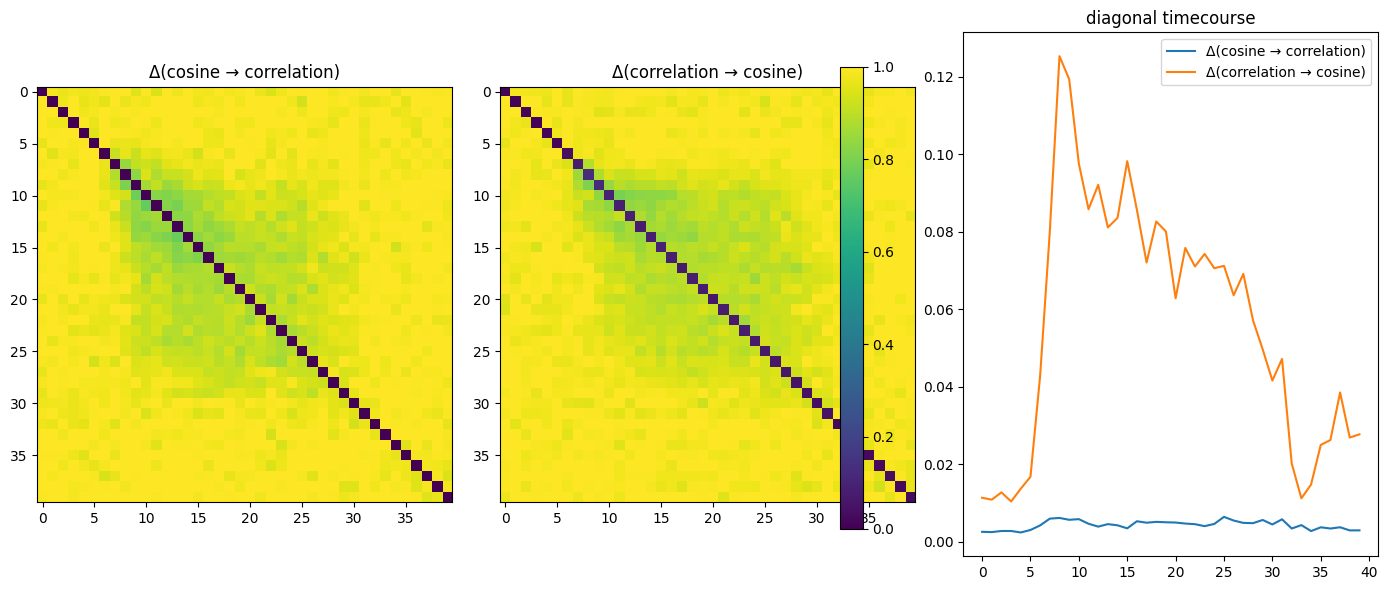

In [ ]:
# check possible interferences between static_dynII and dynII...

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

# Plot both images with the same limits
im = ax[0].imshow(dynII_A2B, vmin=0, vmax=1)
ax[0].set_title(f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
ax[1].imshow(dynII_B2A, vmin=0, vmax=1)
ax[1].set_title(f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
fig.colorbar(im, ax=ax[:2], fraction=0.046, pad=0.04)  # fraction/pad adjust size/spacing
ax[2].plot(np.diag(dynII_A2B), label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
ax[2].plot(np.diag(dynII_B2A), label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
ax[2].set_title("diagonal timecourse")
ax[2].legend()
# Add one colorbar for both axes
plt.tight_layout()
plt.show()


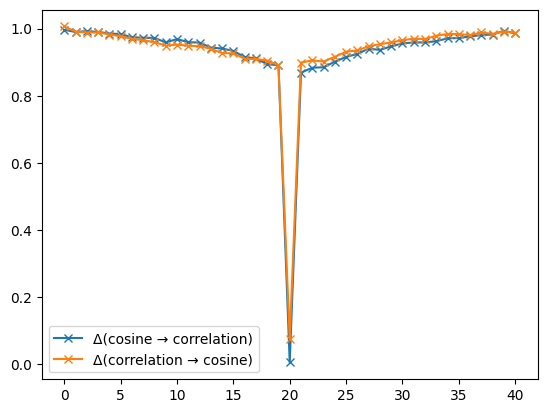

In [ ]:
from general_utils.utils import get_lagplot, get_lagplot_subset
plt.plot(get_lagplot_subset(dynII_A2B, np.arange(10,30)), marker="x", label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(get_lagplot_subset(dynII_B2A, np.arange(10,30)), marker='x', label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
plt.legend()

### model-based static dynamic II

In [38]:
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; layer_name = 'blocks.0.mlp.fc2'

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]

In [ ]:
np.savetxt("/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/for_alessandro/features_block_0.csv", features, delimiter=",")


In [50]:
np.savetxt("/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/for_alessandro/neural_activity_100ms.csv", ba_raster.get_array()[:,10,:], delimiter=",")

In [ ]:
np.loadtxt("/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/for_alessandro/neural_activity_100ms.csv", ba_raster.get_array()[:,10,:], delimiter=",")

0.23744862


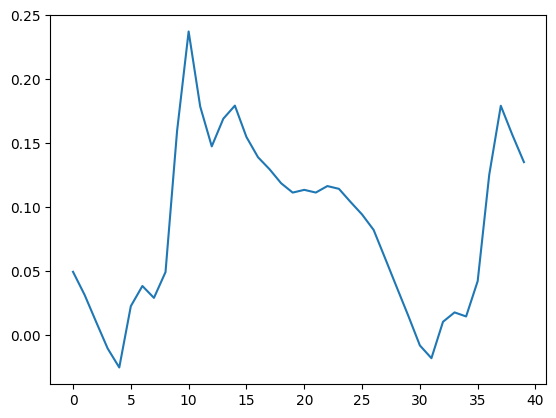

In [51]:
print(ba_raster.get_array()[:,10,:].mean())
plt.plot(ba_raster.get_array()[:,:,:].mean(axis=(0,2)))


In [45]:
np.loadtxt("/Users/tizianocausin/livingstone_lab_local/for_alessandro/neural_activity_100ms.csv", delimiter=",").shape

(19, 4377)

keep only the first 1000 images to speed up the analyses

In [ ]:
try_raster = TimeSeries(ba_raster.get_array()[:,:,:1000], raster.get_fs()) 
feats = features[:,:1000] 

In [ ]:
dyn_ii_obj = dynInformationImbalance("cosine", "cosine", cfg.k)
dyn_ii_obj.compute_RDM_timeseries(try_raster, "signal")
dyn_ii_obj.compute_RDM(feats, "model")

array([0.08431035, 0.03992951, 0.03756309, ..., 0.11653143, 0.00868082,
       0.09164238])

In [ ]:
dyn_ii_obj.compute_distance_ranks("model")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")

In [ ]:
stat_dyn_A2B, stat_dyn_B2A = dyn_ii_obj.compute_both_static_dynII()

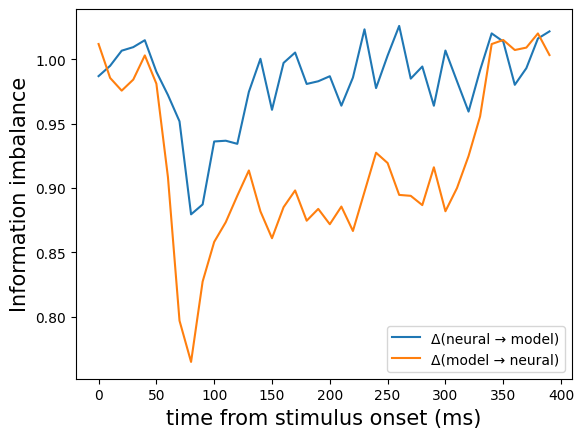

In [ ]:
plt.plot(np.arange(len(stat_dyn_A2B))*1000//cfg.new_fs, stat_dyn_A2B.get_array(), label=f"{chr(916)}(neural {chr(8594)} model)")
plt.plot(np.arange(len(stat_dyn_A2B))*1000//cfg.new_fs, stat_dyn_B2A.get_array(), label=f"{chr(916)}(model {chr(8594)} neural)")
plt.ylabel("Information imbalance", fontsize=15)
plt.xlabel("time from stimulus onset (ms)", fontsize=15)
plt.legend()

In [19]:
def static_dynII_modeling(paths, raster, model, metric_signal, metric_model, k, dyn_ii_obj=None):
    if dyn_ii_obj is None:
        dyn_ii_obj = dynInformationImbalance(metric_signal, metric_model, k)
        dyn_ii_obj.compute_RDM_timeseries(raster, "signal")
        dyn_ii_obj.compute_distance_ranks_timeseries("signal")
    # end if dyn_ii_obj is not None:
    dyn_ii_obj.compute_RDM(model, "model")
    dyn_ii_obj.compute_distance_ranks("model")
    stat_dyn_A2B, stat_dyn_B2A = dyn_ii_obj.compute_both_static_dynII()
    return dyn_ii_obj, stat_dyn_A2B, stat_dyn_B2A
# EOF

In [8]:
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; layer_name = 'blocks.16.mlp.fc2'

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]

In [35]:
from general_utils.utils import get_relevant_output_layers
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; cfg.pkg = 'timm'
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
dyn_ii_obj = dynInformationImbalance("cosine", "euclidean", cfg.k)
dyn_ii_obj.compute_RDM_timeseries(TimeSeries(ba_raster.get_array()[:,:,:1000],ba_raster.get_fs()) , "signal")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")
A2B_layers_list_euccos = []
B2A_layers_list_euccos = []
for layer_name in layers[:]:
    feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
    features = np.load(feats_filename)["arr_0"][:, :1000]
    dyn_ii_obj, A2B, B2A = static_dynII_modeling(paths, ba_raster, features, "cosine", "_", 1, dyn_ii_obj=dyn_ii_obj)
    A2B_layers_list_euccos.append(A2B)
    B2A_layers_list_euccos.append(B2A)
    print_wise(f"computed layer {layer_name}")


17:40:46 - computed layer blocks.0.mlp.fc2
17:40:46 - computed layer blocks.1.mlp.fc2
17:40:46 - computed layer blocks.2.mlp.fc2
17:40:46 - computed layer blocks.3.mlp.fc2
17:40:46 - computed layer blocks.4.mlp.fc2
17:40:47 - computed layer blocks.5.mlp.fc2
17:40:47 - computed layer blocks.6.mlp.fc2
17:40:47 - computed layer blocks.7.mlp.fc2
17:40:47 - computed layer blocks.8.mlp.fc2
17:40:47 - computed layer blocks.9.mlp.fc2
17:40:48 - computed layer blocks.10.mlp.fc2
17:40:48 - computed layer blocks.11.mlp.fc2
17:40:48 - computed layer blocks.12.mlp.fc2
17:40:48 - computed layer blocks.13.mlp.fc2
17:40:48 - computed layer blocks.14.mlp.fc2
17:40:49 - computed layer blocks.15.mlp.fc2
17:40:49 - computed layer blocks.16.mlp.fc2
17:40:49 - computed layer blocks.17.mlp.fc2
17:40:49 - computed layer blocks.18.mlp.fc2
17:40:49 - computed layer blocks.19.mlp.fc2
17:40:50 - computed layer blocks.20.mlp.fc2
17:40:50 - computed layer blocks.21.mlp.fc2
17:40:50 - computed layer blocks.22.mlp.fc

In [23]:
from general_utils.utils import get_relevant_output_layers
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; cfg.pkg = 'timm'
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
dyn_ii_obj = dynInformationImbalance("cosine", "cosine", cfg.k)
dyn_ii_obj.compute_RDM_timeseries(TimeSeries(ba_raster.get_array()[:,:,:1000],ba_raster.get_fs()) , "signal")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")
A2B_layers_list_cos = []
B2A_layers_list_cos = []
for layer_name in layers[:]:
    feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
    features = np.load(feats_filename)["arr_0"][:, :1000]
    dyn_ii_obj, A2B, B2A = static_dynII_modeling(paths, ba_raster, features, "cosine", "_", 1, dyn_ii_obj=dyn_ii_obj)
    A2B_layers_list_euccos.append(A2B)
    B2A_layers_list_euccos.append(B2A)
    print_wise(f"computed layer {layer_name}")


17:34:40 - computed layer blocks.0.mlp.fc2
17:34:40 - computed layer blocks.1.mlp.fc2
17:34:40 - computed layer blocks.2.mlp.fc2
17:34:40 - computed layer blocks.3.mlp.fc2
17:34:40 - computed layer blocks.4.mlp.fc2
17:34:40 - computed layer blocks.5.mlp.fc2
17:34:40 - computed layer blocks.6.mlp.fc2
17:34:40 - computed layer blocks.7.mlp.fc2
17:34:41 - computed layer blocks.8.mlp.fc2
17:34:41 - computed layer blocks.9.mlp.fc2
17:34:41 - computed layer blocks.10.mlp.fc2
17:34:41 - computed layer blocks.11.mlp.fc2
17:34:41 - computed layer blocks.12.mlp.fc2
17:34:41 - computed layer blocks.13.mlp.fc2
17:34:41 - computed layer blocks.14.mlp.fc2
17:34:41 - computed layer blocks.15.mlp.fc2
17:34:42 - computed layer blocks.16.mlp.fc2
17:34:42 - computed layer blocks.17.mlp.fc2
17:34:42 - computed layer blocks.18.mlp.fc2
17:34:42 - computed layer blocks.19.mlp.fc2
17:34:42 - computed layer blocks.20.mlp.fc2
17:34:42 - computed layer blocks.21.mlp.fc2
17:34:42 - computed layer blocks.22.mlp.fc

In [13]:
import pickle as pkl
# with open("/Users/tizianocausin/Desktop/A2B_layers_list_euc_temp.pkl", "wb") as f:
#     pkl.dump(A2B_layers_list_euc, f)
# with open("/Users/tizianocausin/Desktop/B2A_layers_list_euc_temp.pkl", "wb") as f:
#     pkl.dump(B2A_layers_list_euc, f)
with open("/Users/tizianocausin/Desktop/A2B_layers_list_cos-euc_temp.pkl", "wb") as f:
    pkl.dump(A2B_layers_list_euc, f)
with open("/Users/tizianocausin/Desktop/B2A_layers_list_cos-euc_temp.pkl", "wb") as f:
    pkl.dump(B2A_layers_list_euc, f)

In [28]:
from general_utils.utils import get_relevant_output_layers
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; cfg.pkg = 'timm'
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
dyn_ii_obj = dynInformationImbalance("cosine", "cosine", 1)
dyn_ii_obj.compute_RDM_timeseries(TimeSeries(ba_raster.get_array()[:,:,:1000],ba_raster.get_fs()), "signal")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")
A2B_layers_list_cos = []
B2A_layers_list_cos = []
for layer_name in layers[:]:
    feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
    features = np.load(feats_filename)["arr_0"][:,:1000]
    dyn_ii_obj, A2B, B2A = static_dynII_modeling(paths, ba_raster, features, "cosine", "cosine", 1, dyn_ii_obj=dyn_ii_obj)
    
    A2B_layers_list_cos.append(A2B)
    B2A_layers_list_cos.append(B2A)
    print_wise(f"computed layer {layer_name}")


17:36:42 - computed layer blocks.0.mlp.fc2
17:36:42 - computed layer blocks.1.mlp.fc2
17:36:42 - computed layer blocks.2.mlp.fc2
17:36:42 - computed layer blocks.3.mlp.fc2
17:36:43 - computed layer blocks.4.mlp.fc2
17:36:43 - computed layer blocks.5.mlp.fc2
17:36:43 - computed layer blocks.6.mlp.fc2
17:36:43 - computed layer blocks.7.mlp.fc2
17:36:43 - computed layer blocks.8.mlp.fc2
17:36:43 - computed layer blocks.9.mlp.fc2
17:36:43 - computed layer blocks.10.mlp.fc2
17:36:43 - computed layer blocks.11.mlp.fc2
17:36:44 - computed layer blocks.12.mlp.fc2
17:36:44 - computed layer blocks.13.mlp.fc2
17:36:44 - computed layer blocks.14.mlp.fc2
17:36:44 - computed layer blocks.15.mlp.fc2
17:36:44 - computed layer blocks.16.mlp.fc2
17:36:44 - computed layer blocks.17.mlp.fc2
17:36:44 - computed layer blocks.18.mlp.fc2
17:36:44 - computed layer blocks.19.mlp.fc2
17:36:45 - computed layer blocks.20.mlp.fc2
17:36:45 - computed layer blocks.21.mlp.fc2
17:36:45 - computed layer blocks.22.mlp.fc

In [58]:
import pickle as pkl
with open("/Users/tizianocausin/Desktop/A2B_layers_list_cos_temp.pkl", "wb") as f:
    pkl.dump(A2B_layers_list_cos, f)
with open("/Users/tizianocausin/Desktop/B2A_layers_list_cos_temp.pkl", "wb") as f:
    pkl.dump(B2A_layers_list_cos, f)


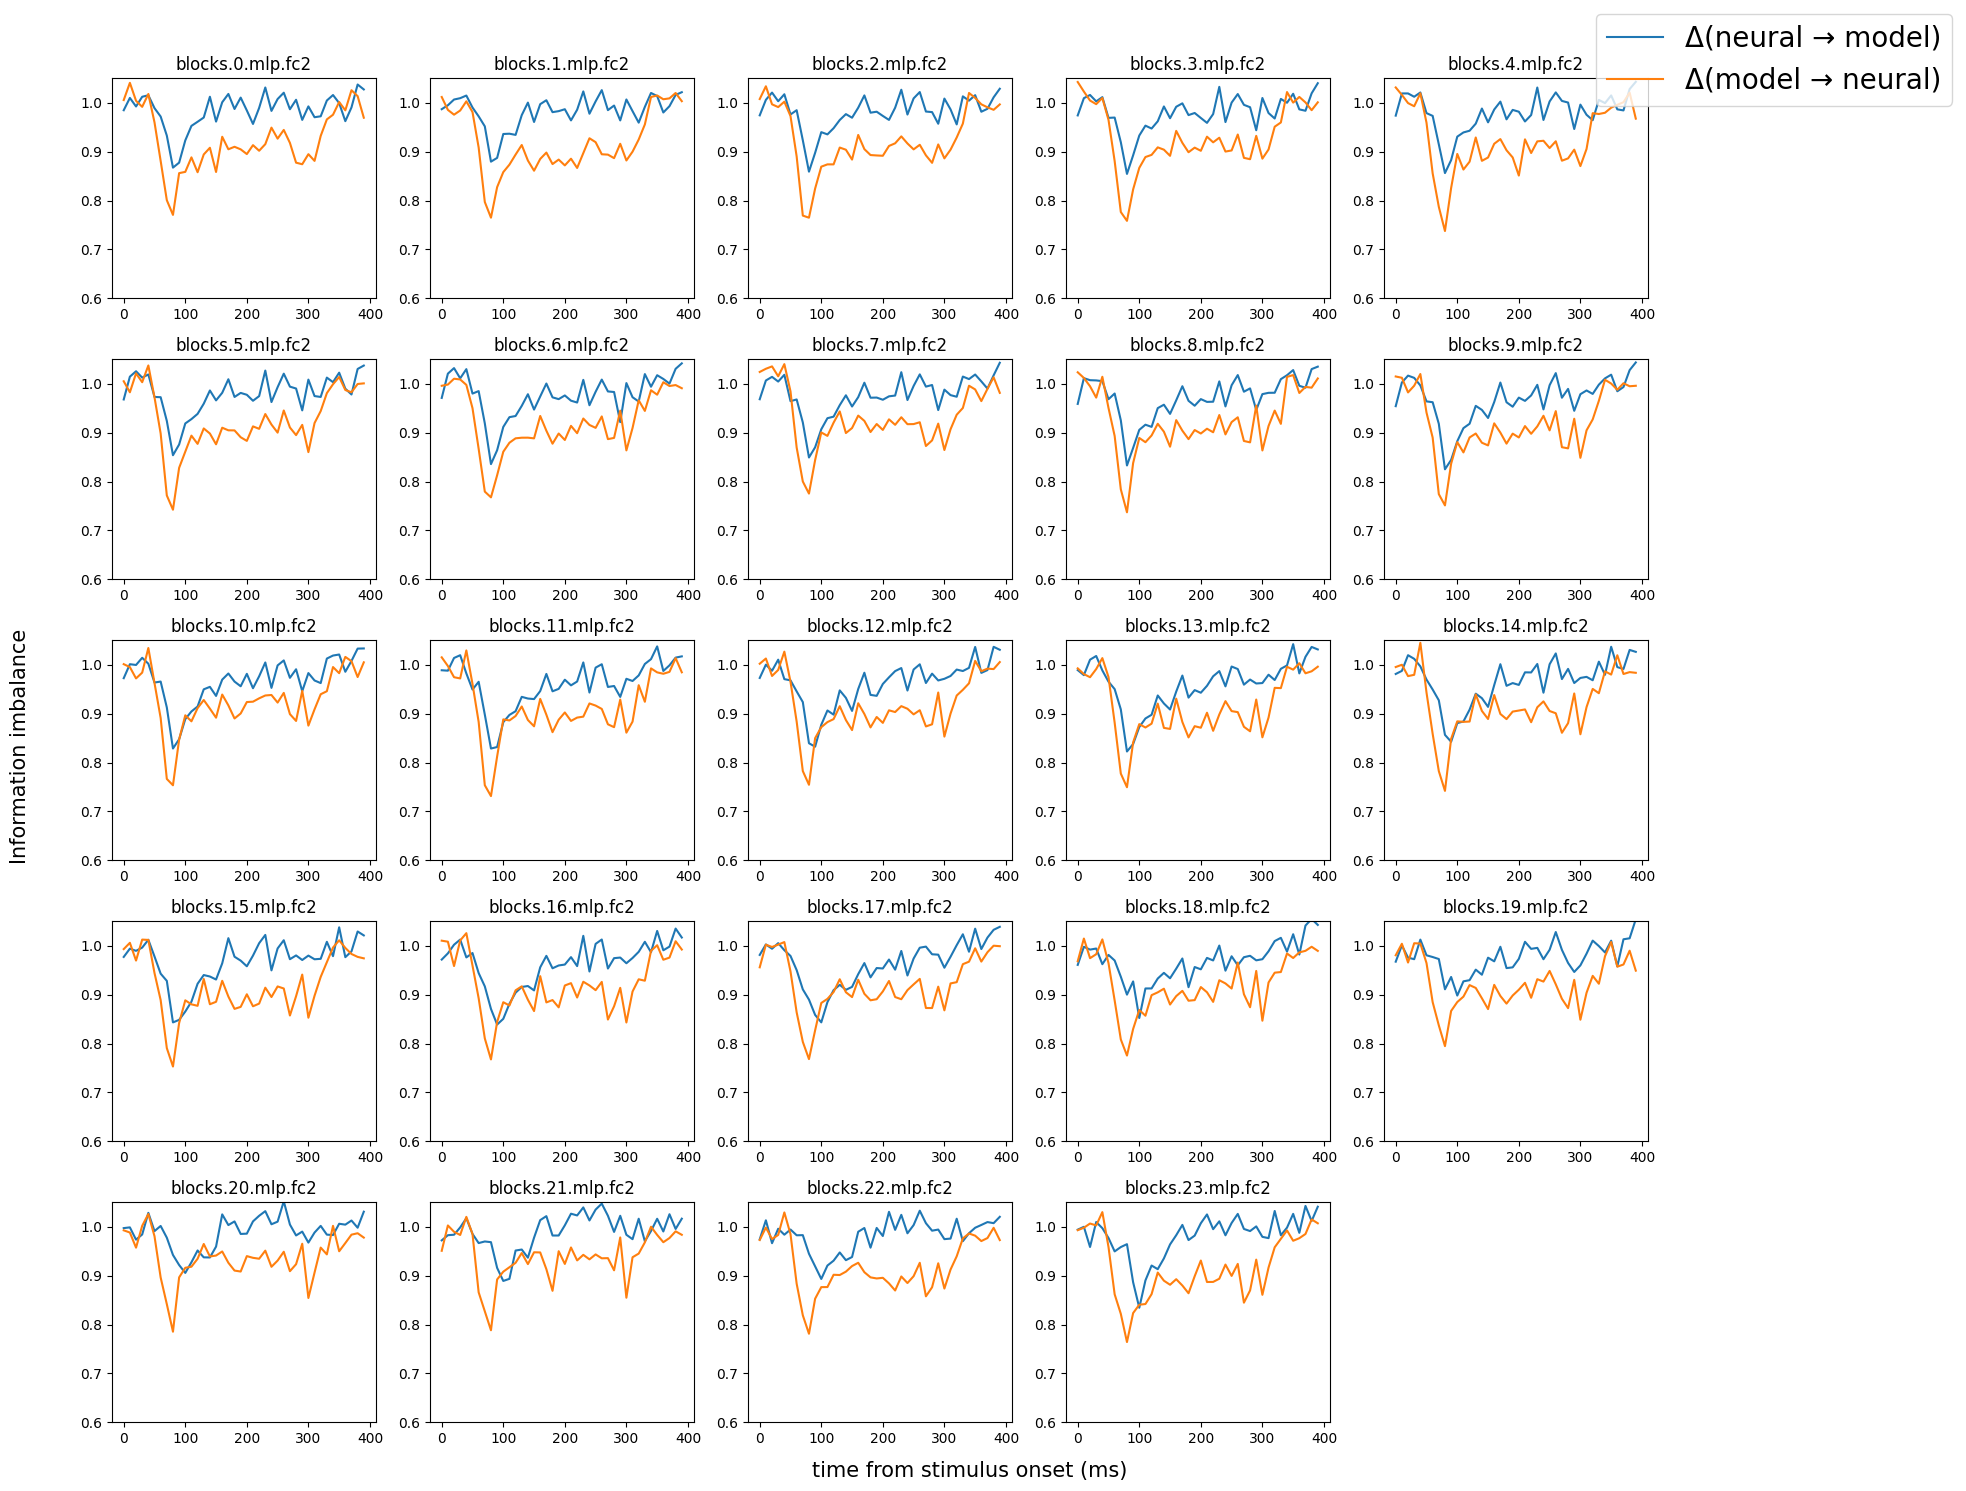

In [30]:
n_cols, n_rows = (len(A2B_layers_list_cos))//5+1, 5
fig, ax = plt.subplots(n_rows, n_cols,figsize=(4*n_cols, 3*n_rows))
ax = ax.flatten()
for idx, (A2B, B2A) in enumerate(zip(A2B_layers_list_cos, B2A_layers_list_cos)):
    if idx != 23:
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, A2B.get_array())#, label=f"{chr(916)}(neural {chr(8594)} model)"))
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, B2A.get_array())#, label=f"{chr(916)}(model {chr(8594)} neural)")
    else:
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, A2B.get_array(), label=f"{chr(916)}(neural {chr(8594)} model)")
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, B2A.get_array(), label=f"{chr(916)}(model {chr(8594)} neural)")
    ax[idx].set_ylim([.6, 1.05])
    ax[idx].set_title(layers[idx])
    # remove unused axes
for a in ax[len(layers):]:
    a.axis("off")

fig.supylabel("Information imbalance", fontsize=15)
fig.supxlabel("time from stimulus onset (ms)", fontsize=15)
fig.legend(fontsize=20)
fig.tight_layout(rect=[0.03, 0, 0.85, .97])


In [14]:
with open("/Users/tizianocausin/Desktop/A2B_layers_list_euc_temp.pkl", "rb") as f:
    obj_A2B = pkl.load(f)
with open("/Users/tizianocausin/Desktop/B2A_layers_list_euc_temp.pkl", "rb") as f:
    obj_B2A = pkl.load(f)

In [37]:
for i in np.arange(24):
    print(np.allclose(A2B_layers_list_cos[i].get_array(),  A2B_layers_list_euccos[i].get_array()))

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


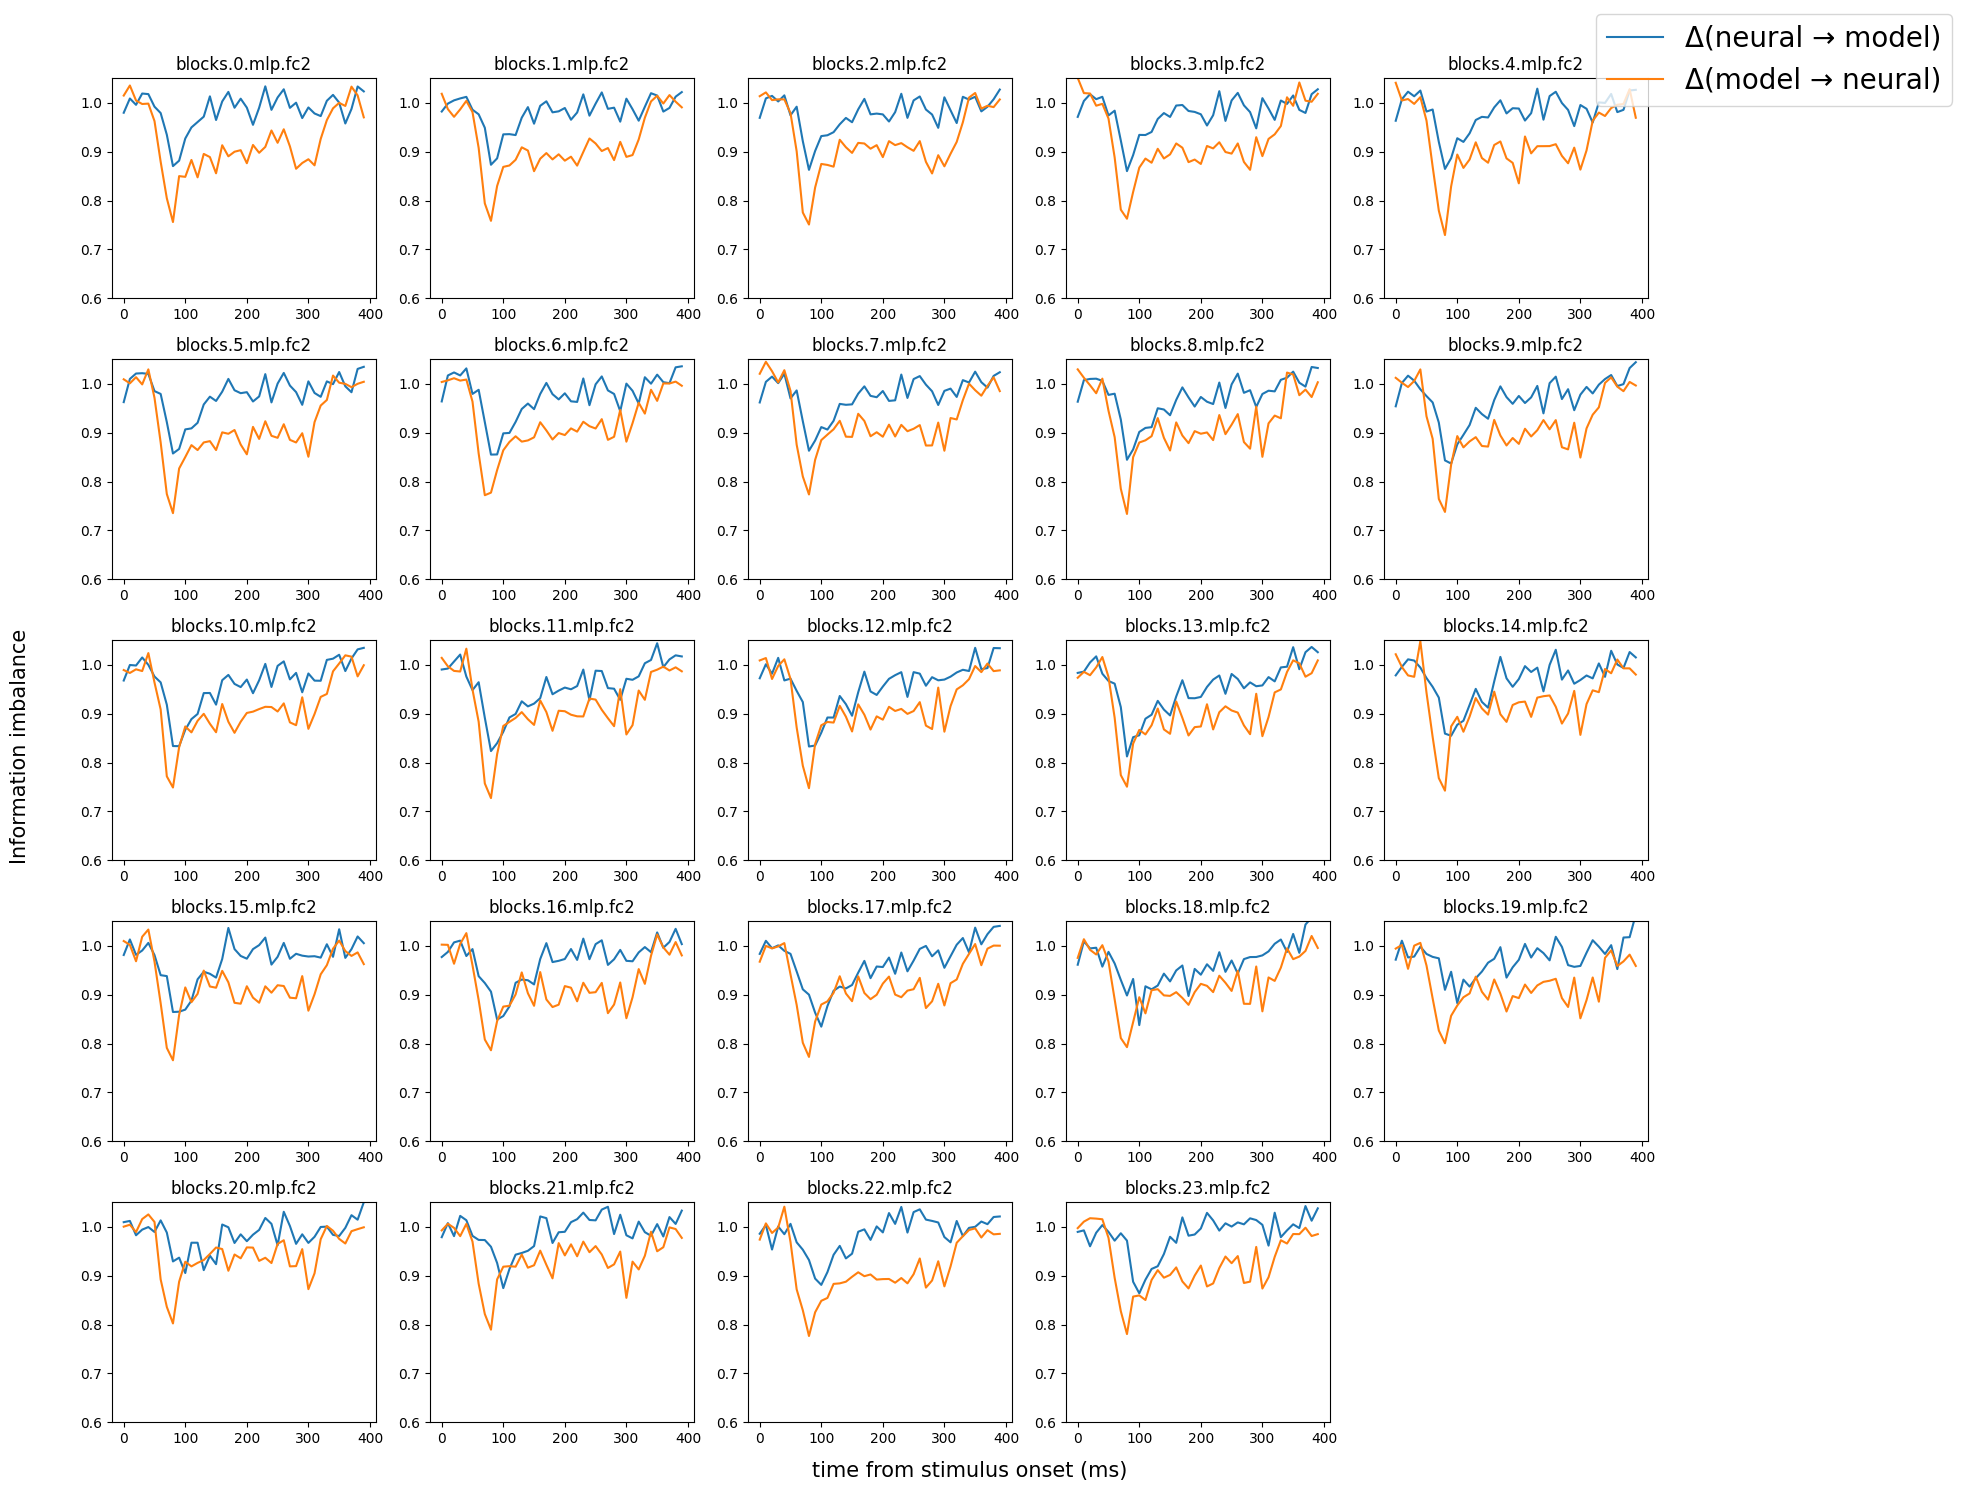

In [36]:
n_cols, n_rows = (len(A2B_layers_list_euc))//5+1, 5
fig, ax = plt.subplots(n_rows, n_cols,figsize=(4*n_cols, 3*n_rows))
ax = ax.flatten()
for idx, (A2B, B2A) in enumerate(zip(A2B_layers_list_euccos, B2A_layers_list_euccos)):
    if idx != 23:
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, A2B.get_array())#, label=f"{chr(916)}(neural {chr(8594)} model)"))
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, B2A.get_array())#, label=f"{chr(916)}(model {chr(8594)} neural)")
    else:
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, A2B.get_array(), label=f"{chr(916)}(neural {chr(8594)} model)")
        ax[idx].plot(np.arange(len(A2B))*1000//cfg.new_fs, B2A.get_array(), label=f"{chr(916)}(model {chr(8594)} neural)")
    ax[idx].set_ylim([.6, 1.05])
    ax[idx].set_title(layers[idx])
    # remove unused axes
for a in ax[len(layers):]:
    a.axis("off")

fig.supylabel("Information imbalance", fontsize=15)
fig.supxlabel("time from stimulus onset (ms)", fontsize=15)
fig.legend(fontsize=20)
fig.tight_layout(rect=[0.03, 0, 0.85, .97])
